In [1]:
# =============================================================================
# Kapiti Coast urban drainage network (UDN) -- preprocessing
# -----------------------------------------------------------------------------
# Builds the two canonical tables consumed by the reconstruction notebooks:
#   df_pipe : pipe_id, material, diameter
#   df_node : node_id, x, y, rimElevation, invertElevation
# from the raw wastewater CSV exports (Kapiti Coast has a single combined
# network, unlike Angers/Auckland's separate wastewater/stormwater files).
# =============================================================================
import pandas as pd
import numpy as np
import function
import importlib

importlib.reload(function)

from function import *

In [2]:
# ── Pipe table ───────────────────────────────────────────────────────────
# Load the wastewater pipe export and keep only the three attributes
# needed downstream.
df_pipe = pd.read_csv("../data/Kapiti Coast/KCDC_Wastewater_Pipes.csv")
df_pipe = df_pipe[["OBJECTID", "pipe_material", "width"]]

In [3]:
# Rename to the canonical schema.
df_pipe = df_pipe.rename(columns={"OBJECTID": "pipe_id", "pipe_material": "material", "width": "diameter"}) 

In [4]:
# Sanity check: any duplicate pipe ids?
df_pipe[df_pipe["pipe_id"].duplicated()]

,pipe_id,material,diameter


In [5]:
# Diameter distribution, used to calibrate the upper bound applied below
# (manuscript Section 2.2.2 approach: inspect the percentiles rather than
# guess a cutoff).
print(df_pipe["diameter"].describe())
print("99 percentile =", np.quantile(df_pipe["diameter"].dropna(), 0.99))
print("99,9 percentile =", np.quantile(df_pipe["diameter"].dropna(), 0.999))

count    7515.000000
mean      165.459082
std        73.047414
min        32.000000
25%       150.000000
50%       150.000000
75%       150.000000
max      1600.000000
Name: diameter, dtype: float64
99 percentile = 525.0
99,9 percentile = 750.0


In [6]:
# Diameters at or below 0 or at/above 5000 mm are treated as physically
# implausible for this network and set to NaN (the pipe itself is kept --
# only its diameter value is discarded, to be reconstructed later).
mask = (df_pipe["diameter"] <= 0.0) | (df_pipe["diameter"] >= 5000)
df_pipe.loc[mask, "diameter"] = np.nan

material
AC       3870
PVC      1586
UPVC     1311
UNK       519
HDPE      271
EW        112
RCON       96
UPVC1      61
PVCSP      36
MDPE       29
UPVC2      27
STEEL      16
PE          5
DI          3
MPVC2       3
CONC        1
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

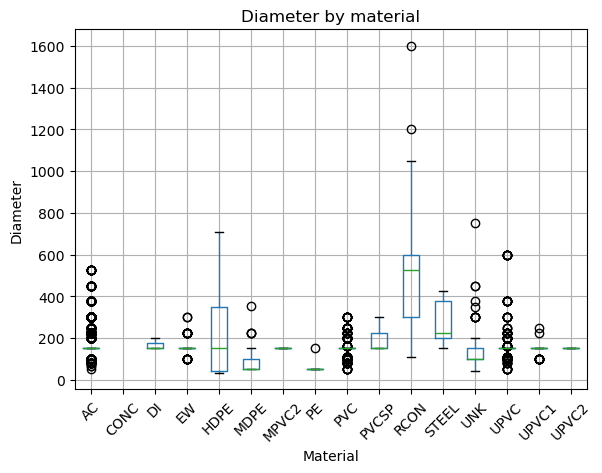

material
Asbestos-cement    3870
Plastic            3329
Undetermined       1104
Concrete            209
Metal                19
Name: count, dtype: int64


<Figure size 640x480 with 0 Axes>

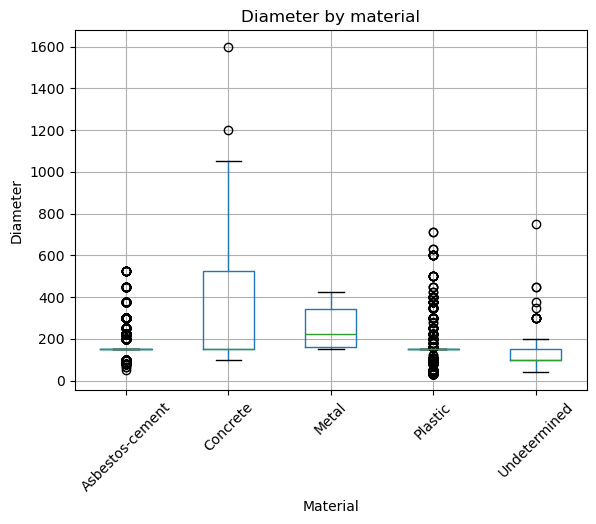

In [7]:
# ── Material category grouping (manuscript Section 2.2.4) ─────────────────
# Kapiti Coast's own raw material vocabulary; note there is no "Glass"
# label in this network's data (the class stays empty, unlike the other
# three networks).
def map_material(mat):
    if mat in plastic:
        return "Plastic"
    elif mat in concrete:
        return "Concrete"
    elif mat in metal:
        return "Metal"
    elif mat in asbestos_cement:
        return "Asbestos-cement"
    elif mat in glass:
        return "Glass"
    else:
        return "Undetermined"

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

plastic = ["PVC", "UPVC", "HDPE", "UPVC1", "PVCSP", "MDPE", "UPVC2", "PE", "MPVC2"]
concrete = ["RCON", "CONC", "EW"]
metal = ["STEEL", "DI"]
asbestos_cement = ["AC"]
glass = []

df_pipe["material"] = df_pipe["material"].apply(map_material)

print(df_pipe["material"].value_counts())

boxplot_mat_dia(df_pipe)

In [8]:
# ── Node table ───────────────────────────────────────────────────────────
# Load the wastewater manhole export, keep the five attributes needed
# downstream (coordinates, rim/invert elevation), and rename them to the
# canonical schema. Coordinates are assumed to already be in the network's
# working CRS (EPSG:2193, NZTM2000); no reprojection is applied here.
df = pd.read_csv("../data/Kapiti Coast/KCDC_Wastewater_Manholes.csv")

df_node = df[["asset_id", "X", "Y", "invert_level_nzvd2016", "cover_level_nzvd2016"]]

df_node = df_node.rename(columns={
    "asset_id": "node_id", "invert_level_nzvd2016": "invertElevation", "cover_level_nzvd2016": "rimElevation", "X": "x", "Y": "y"
})

In [9]:
# Sanity check: any duplicate node ids? (Investigated below and fixed in
# the next two cells.)
df_node[df_node["node_id"].duplicated(keep = False)]

,node_id,x,y,invertElevation,rimElevation
2589,KWWN002203,1766384.834,5.466171e+06,NaN,NaN
2802,KWWN002203,1766409.317,5.466164e+06,10.18,11.6


In [10]:
# Check whether this id is already in use elsewhere (which would create a
# collision if assigned again below).
df_node[df_node["node_id"] == "KWWN012203"]

,node_id,x,y,invertElevation,rimElevation


In [11]:
# One-off, position-based fix for the duplicate node id found above.
# NOTE: re-verify this row index if the source CSV is refreshed.
df_node.loc[2589, "node_id"] = "KWWN012203"

In [12]:
# Sanity check: any two nodes sharing the exact same coordinates?
df_node[df_node[["x","y"]].duplicated(keep = False)]

,node_id,x,y,invertElevation,rimElevation
3726,KWWN003526,1767382.474,5.471895e+06,3.85,5.62
7780,KWWN007870,1767382.474,5.471895e+06,5.89,7.24
8209,KWWN010415,1771555.040,5.474039e+06,NaN,NaN
8210,KWWN012479,1780123.747,5.486222e+06,NaN,NaN
8820,KWWN010408,1771555.040,5.474039e+06,NaN,NaN
8939,KWWN012478,1780123.747,5.486222e+06,NaN,NaN


In [13]:
# Collapse coincident-location duplicates by keeping the first one
df_node = df_node.drop_duplicates(subset=["x","y"],keep="first").reset_index(drop=True)


In [14]:
# ── Removal of physically impossible node-level values (Section 2.2.2) ────
# Elevations outside the admissible range for this network are discarded,
# and invert elevations exceeding the rim elevation at the same node are
# set to NaN as a hydraulically impossible configuration.
columns = [
    "invertElevation",
    "rimElevation",
]

nan_before = df_node[columns].isna().sum()

df_node["invertElevation"] = discardHeightImpossible(df_node, "invertElevation", -5, 200)
df_node["rimElevation"] = discardHeightImpossible(df_node, "rimElevation", 0, 200)

mask = df_node["invertElevation"] > df_node["rimElevation"]
df_node.loc[mask, "invertElevation"] = np.nan
df_node.loc[mask, "rimElevation"] = np.nan

nan_after = df_node[columns].isna().sum()

nan_diff = pd.DataFrame({
    "NaN_before": nan_before,
    "NaN_after": nan_after,
    "increase": nan_after - nan_before,
    "increase_%": ((nan_after - nan_before) / len(df_node) * 100).round(2)
})

print(nan_diff)

                 NaN_before  NaN_after  increase  increase_%
invertElevation        2883       2885         2        0.02
rimElevation           2849       2850         1        0.01


In [15]:
# ── Serialisation ───────────────────────────────────────────────────────
# Save the cleaned pipe and node tables to disk (pickle format) for the
# downstream reconstruction notebooks.
df_pipe.to_pickle("../data/Kapiti Coast/df_pipe_Kapiti.pkl")
df_node.to_pickle("../data/Kapiti Coast/df_node_Kapiti.pkl")